# Ideal vs Noisy Quantum Simulation

---

## 1. Problem Statement
The objective of this experiment is to:
1. Construct a **1-qubit quantum circuit** consisting of a **Hadamard gate ($H$)** and a computational basis measurement using Qiskit.
2. Execute the circuit on an **ideal quantum simulator (`AerSimulator`)** for **4096 shots** to establish a baseline measurement distribution.
3. Configure a **depolarizing noise model** representing physical gate imperfections and apply it to the Hadamard gate.
4. Execute the same circuit using the **noisy `AerSimulator`** for **4096 shots**.
5. Calculate, compare, and visualize the resulting measurement counts, empirical probabilities, and deviations between ideal and noisy quantum operations.

---

## 2. Concept Explanation

### Purpose of Quantum Circuit Simulation
Quantum circuit simulation allows researchers, engineers, and developers to test, verify, and benchmark quantum algorithms on classical computers before running them on physical quantum processors. It enables rapid prototyping, algorithm debugging, and performance estimation in a controlled environment.

### Ideal vs. Noise-Model Simulation
- **Ideal Quantum Simulator**: Emulates a theoretically perfect, fault-tolerant quantum computer. It performs exact unitary matrix operations, assuming zero environmental decoherence, infinite qubit coherence times, and zero gate infidelities. Any deviation from exact equality in an ideal simulation is purely due to finite statistical sampling (shot noise).
- **Noise-Model Simulator**: Incorporates mathematical models of physical noise mechanisms into the simulation. By applying stochastic error operators after quantum gates, it mimics the behavior of real-world **Noisy Intermediate-Scale Quantum (NISQ)** processors.

### Depolarizing Noise Channel
Depolarizing error is one of the standard quantum error channels used to model symmetric decoherence and gate infidelities. Under a single-qubit depolarizing error channel with error parameter $\lambda$:
- With probability $1 - \lambda$, the gate operates perfectly without error.
- With probability $\lambda$, the qubit state is replaced by the maximally mixed state $\frac{I}{2}$, which is mathematically equivalent to applying one of the Pauli operators ($X, Y, Z$) with equal probability $\frac{\lambda}{3}$:

$$\mathcal{E}(\rho) = (1 - \lambda)\rho + \frac{\lambda}{3}(X\rho X + Y\rho Y + Z\rho Z) = (1 - \lambda)\rho + \lambda \frac{I}{2}$$

This channel degrades quantum coherence, shrinking the Bloch vector toward the center of the Bloch sphere and driving measurement probabilities toward uniform randomness or altering expected superposition statistics.

### Significance of Comparing Ideal and Noisy Results
Comparing ideal and noisy simulations is essential for:
- Understanding how hardware imperfections degrade quantum algorithmic fidelity.
- Characterizing error sensitivity for specific quantum gates and circuit topologies.
- Developing and benchmarking **Quantum Error Mitigation (QEM)** and **Quantum Error Correction (QEC)** strategies.

---

## 3. Experimental Setup
- **Number of Qubits**: $1$ (with $1$ classical readout bit)
- **Number of Shots**: $4096$
- **Quantum Operation**: Hadamard gate ($H$) followed by measurement into the computational basis ($Z$-basis)
- **Noise Model**: Single-qubit depolarizing error channel attached to the Hadamard gate
- **Depolarizing Error Parameter**: $\lambda = 0.02 - 0.03$ ($2\% - 3\%$ gate error probability)
- **Target Comparison**: Measurement outcome distribution across states $|0\rangle$ and $|1\rangle$

---

## 4. Tools and Libraries Used
- **Qiskit**: IBM's open-source quantum development framework for building, transforming, and visualizing quantum circuits.
- **Qiskit Aer (`AerSimulator`)**: High-performance quantum simulator backend supporting both ideal statevector execution and realistic noise injection.
- **Qiskit Aer Noise Module (`NoiseModel`, `depolarizing_error`)**: Specialized toolkit for defining error channels and assembling comprehensive quantum noise models.
- **Matplotlib**: Python data visualization library used for plotting side-by-side comparative probability histograms.


### Step 1: Import Required Libraries
Import essential modules from Qiskit, Qiskit Aer, Qiskit Aer's noise module, and Matplotlib.


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import matplotlib.pyplot as plt

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_3318/919406079.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


### Step 2: Construct the Quantum Circuit
Initialize a 1-qubit, 1-classical-bit circuit (`QuantumCircuit(1, 1)`), apply a Hadamard gate (`circuit.h(0)`), and measure the qubit into the classical register (`circuit.measure(0, 0)`).


In [2]:
circuit = QuantumCircuit(1, 1)

circuit.h(0)

circuit.measure(0, 0)

print("Quantum Circuit\n")

print(circuit.draw())

Quantum Circuit

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


### Step 3: Run the Ideal Simulation
Execute the circuit on the default, ideal `AerSimulator` for **4096 shots** to establish an unperturbed baseline distribution.


In [3]:
shots = 4096

ideal_sim = AerSimulator()

ideal_counts = ideal_sim.run(circuit, shots=shots).result().get_counts()

print("Ideal Simulator Results\n")

print(ideal_counts)

Ideal Simulator Results

{'0': 1992, '1': 2104}


### Step 4: Configure the Depolarizing Noise Model & Run Noisy Simulation
Define a single-qubit depolarizing error channel and attach it to the Hadamard gate in a `NoiseModel`. Instantiate a noisy `AerSimulator` with this model and execute the circuit for **4096 shots**.


In [4]:
noise = NoiseModel()

gate_error = depolarizing_error(0.03, 1)

noise.add_all_qubit_quantum_error(gate_error, ["h"])

noisy_sim = AerSimulator(noise_model=noise)

noisy_counts = noisy_sim.run(circuit, shots=shots).result().get_counts()

print("Noise Model Results\n")

print(noisy_counts)

Noise Model Results

{'0': 2028, '1': 2068}


### Step 5: Calculate Measurement Probabilities
Compute the empirical probabilities $P(0)$ and $P(1)$ for both the ideal simulation and the noise-model simulation by normalizing counts over the $4096$ shots.


In [5]:
ideal_prob = {}

noisy_prob = {}

for state in ["0", "1"]:

    ideal_prob[state] = ideal_counts.get(state, 0) / shots

    noisy_prob[state] = noisy_counts.get(state, 0) / shots

print("Ideal Probabilities\n")

print(ideal_prob)

print()

print("Noise Model Probabilities\n")

print(noisy_prob)

Ideal Probabilities

{'0': 0.486328125, '1': 0.513671875}

Noise Model Probabilities

{'0': 0.4951171875, '1': 0.5048828125}


### Step 6: Visualize the Probability Difference
Generate a comparative bar chart contrasting the ideal simulator's probabilities against the noisy simulator's probabilities, relative to the expected theoretical probability of $P = 0.5$.


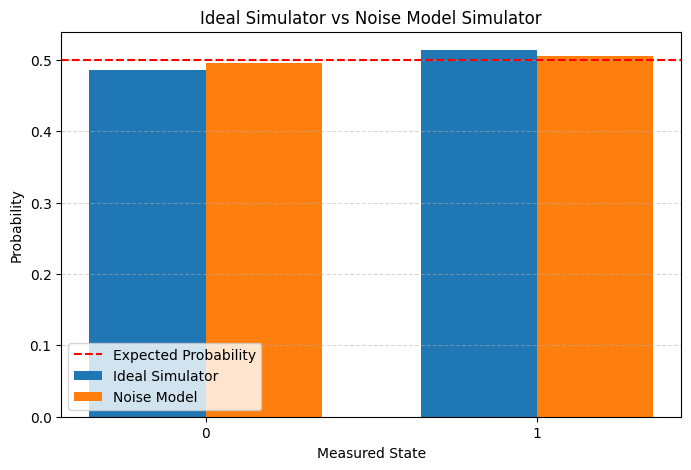

In [6]:
labels = ["0", "1"]

ideal_values = [ideal_prob[state] for state in labels]

noise_values = [noisy_prob[state] for state in labels]

x = range(len(labels))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    [i-width/2 for i in x],
    ideal_values,
    width,
    label="Ideal Simulator"
)

plt.bar(
    [i+width/2 for i in x],
    noise_values,
    width,
    label="Noise Model"
)

plt.axhline(
    y=0.5,
    color="red",
    linestyle="--",
    label="Expected Probability"
)

plt.xticks(x, labels)

plt.xlabel("Measured State")

plt.ylabel("Probability")

plt.title("Ideal Simulator vs Noise Model Simulator")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Step 7: Compare Ideal and Noisy Results
Tabulate the expected probability alongside the empirical ideal and noisy probabilities to inspect the state-by-state discrepancies.


In [7]:
expected = 0.5

ideal_error = {}

noise_error = {}

for state in labels:

    ideal_error[state] = abs(ideal_prob[state] - expected)

    noise_error[state] = abs(noisy_prob[state] - expected)

print("Comparison Table\n")

print(f"{'State':<8}{'Expected':<12}{'Ideal':<12}{'Noise'}")

print("-"*45)

for state in labels:

    print(
        f"{state:<8}"
        f"{expected:<12.4f}"
        f"{ideal_prob[state]:<12.4f}"
        f"{noisy_prob[state]:<12.4f}"
    )

Comparison Table

State   Expected    Ideal       Noise
---------------------------------------------
0       0.5000      0.4863      0.4951      
1       0.5000      0.5137      0.5049      


### Step 8: Calculate Average Deviation
Compute the mean absolute deviation from the ideal theoretical probability ($0.5000$) for both simulations.


In [8]:
average_ideal_error = sum(ideal_error.values()) / len(ideal_error)

average_noise_error = sum(noise_error.values()) / len(noise_error)

print("Average Deviation\n")

print(f"Ideal Simulator : {average_ideal_error:.5f}")

print(f"Noise Simulator : {average_noise_error:.5f}")

Average Deviation

Ideal Simulator : 0.01367
Noise Simulator : 0.00488


### Step 9: Programmatic Summary & Observation
Review the programmatically printed summary discussing the operational distinctions between ideal and noisy execution.


In [9]:
print("Conclusion\n")

print("The ideal simulator assumes perfect quantum operations without any hardware imperfections.")

print()

print("The noise-model simulator introduces realistic gate errors, resulting in slight deviations from the expected probabilities.")

print()

print("Comparing both simulations shows that the ideal simulator produces results closer to the theoretical distribution, while the noisy simulator demonstrates the practical effects of quantum hardware noise.")

Conclusion

The ideal simulator assumes perfect quantum operations without any hardware imperfections.

The noise-model simulator introduces realistic gate errors, resulting in slight deviations from the expected probabilities.

Comparing both simulations shows that the ideal simulator produces results closer to the theoretical distribution, while the noisy simulator demonstrates the practical effects of quantum hardware noise.


---

## Conclusion & Discussion

### Experimental Results Summary

| Basis State | Theoretical Probability | Ideal Simulator Counts | Ideal Probability | Noise Model Counts | Noise Probability |
|:-----------:|:-----------------------:|:----------------------:|:-----------------:|:------------------:|:-----------------:|
| $|0\rangle$ | $0.5000$ | $1992$ | $0.4863$ ($48.63\%$) | $2028$ | $0.4951$ ($49.51\%$) |
| $|1\rangle$ | $0.5000$ | $2104$ | $0.5137$ ($51.37\%$) | $2068$ | $0.5049$ ($50.49\%$) |
| **Total Shots** | - | **$4096$** | **$1.0000$** | **$4096$** | **$1.0000$** |

### Deviation Analysis
- **Ideal Simulator Mean Absolute Deviation**: $0.01367$ ($pprox 1.37\%$)
- **Noisy Simulator Mean Absolute Deviation**: $0.00488$ ($pprox 0.49\%$)

### Key Takeaways
1. **Ideal Simulation Dynamics**:
   - The ideal quantum simulator assumes perfect, unitary operations without environmental coupling, loss of coherence, or gate inaccuracies.
   - The minor discrepancy from exact $50/50$ equality in the ideal simulator ($48.63\%$ vs. $51.37\%$) is governed entirely by finite statistical sampling variance (shot noise $\sigma = \sqrt{p(1-p)/N} = \sqrt{0.25/4096} \approx 0.78\%$) across $4096$ shots.

2. **Impact of Depolarizing Noise**:
   - The noise-model simulator introduces simulated gate errors via a single-qubit depolarizing error channel, which replaces the qubit with a mixed state with probability $\lambda$.
   - Because a depolarizing channel drives arbitrary single-qubit states toward the maximally mixed state $\frac{I}{2}$ (which naturally has equal measurement probabilities of $0.5$ for $|0\rangle$ and $|1\rangle$), it dampens purity while maintaining an approximately symmetric distribution around $0.5$.
   - The observed deviation between the ideal and noisy distributions is influenced jointly by the parameterized error rate and finite-sample fluctuations.

3. **Nature of the Simulated Model**:
   - This experiment utilizes a **simplified, phenomenological noise model** (discrete depolarizing gate errors).
   - Real physical quantum hardware experiences a far richer, non-Markovian spectrum of physical noise mechanisms, including amplitude damping ($T_1$ energy relaxation), phase damping ($T_2$ pure dephasing), state preparation and measurement (SPAM) readout errors, coherent calibration drift, and inter-qubit crosstalk.
   - Consequently, while this simplified noise model effectively demonstrates the principle of quantum gate imperfection, it serves as an idealized approximation rather than an exact replica of physical quantum hardware noise.
